# Waste Classification with CNN - Machine Learning HW2

**Davide De Blasio - 2082600**

**December 2025**

This project performs comprehensive image classification, preprocessing, dimensionality reduction, and convolutional neural network modeling on the [RealWaste Dataset (Kaggle)](https://www.kaggle.com/datasets/joebeachcapital/realwaste)

**Target Variable:** Waste Category - Multi-class Classification Task

**Approach:** We train Convolutional Neural Networks (CNN) on three versions of the dataset:
1. Original images (full resolution features)
2. PCA-reduced features  
3. Autoencoder-reduced features

We compare performance, training time, and computational efficiency across all three approaches.

## 1. Environment Setup

In [3]:
# Dataset download
import kagglehub

# Data manipulation
import pandas as pd
import numpy as np
import os
import shutil
import random
from math import floor
from collections import Counter

# Image processing
from PIL import Image

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# PyTorch and torchvision
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Sklearn for preprocessing and dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_fscore_support
)

# Progress bars and time tracking
from tqdm import tqdm
import time

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Device detection with MPS support for Apple Silicon
if torch.backends.mps.is_available():
    device = torch.device("mps")
    torch.mps.manual_seed(42)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed(42)
else:
    device = torch.device("cpu")

print("Libraries imported successfully!")
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

Libraries imported successfully!
Device: mps
PyTorch version: 2.6.0


## 2. Data Acquisition

In [20]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("joebeachcapital/realwaste")

# Navigate to dataset directory
dataset_root = os.path.join(path, "realwaste-main", "RealWaste")

print(f"Dataset path: {dataset_root}")
print("Dataset downloaded successfully!")

# List all waste categories (subdirectories)
categories = sorted([d for d in os.listdir(dataset_root) 
                     if os.path.isdir(os.path.join(dataset_root, d))])

print(f"\nNumber of waste categories: {len(categories)}")
print(f"\nWaste categories:")
for i, cat in enumerate(categories, 1):
    cat_path = os.path.join(dataset_root, cat)
    num_images = len([f for f in os.listdir(cat_path) if f.endswith('.jpg')])
    print(f"  {i}. {cat}: {num_images} images")

Dataset path: /Users/davide/.cache/kagglehub/datasets/joebeachcapital/realwaste/versions/1/realwaste-main/RealWaste
Dataset downloaded successfully!

Number of waste categories: 9

Waste categories:
  1. Cardboard: 461 images
  2. Food Organics: 411 images
  3. Glass: 420 images
  4. Metal: 790 images
  5. Miscellaneous Trash: 495 images
  6. Paper: 500 images
  7. Plastic: 921 images
  8. Textile Trash: 318 images
  9. Vegetation: 436 images


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Statistics

In [ ]:
# Count images per category
class_counts = {}
total_images = 0

for cat in categories:
    cat_path = os.path.join(dataset_root, cat)
    images = [f for f in os.listdir(cat_path) if f.endswith('.jpg')]
    class_counts[cat] = len(images)
    total_images += len(images)

print(f"Total number of images: {total_images}")
print(f"\nClass distribution:")
for cat, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / total_images) * 100
    print(f"  {cat}: {count} images ({percentage:.2f}%)")

# Check for class imbalance
max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count
print(f"\nClass imbalance ratio: {imbalance_ratio:.2f}:1 (max/min)")
if imbalance_ratio > 2.0:
    print("Significant class imbalance detected")
else:
    print("Dataset is relatively balanced")

Total number of images: 4752

Class distribution:
  Plastic: 921 images (19.38%)
  Metal: 790 images (16.62%)
  Paper: 500 images (10.52%)
  Miscellaneous Trash: 495 images (10.42%)
  Cardboard: 461 images (9.70%)
  Vegetation: 436 images (9.18%)
  Glass: 420 images (8.84%)
  Food Organics: 411 images (8.65%)
  Textile Trash: 318 images (6.69%)

Class imbalance ratio: 2.90:1 (max/min)
Significant class imbalance detected


### 3.2 Visualize Class Distribution

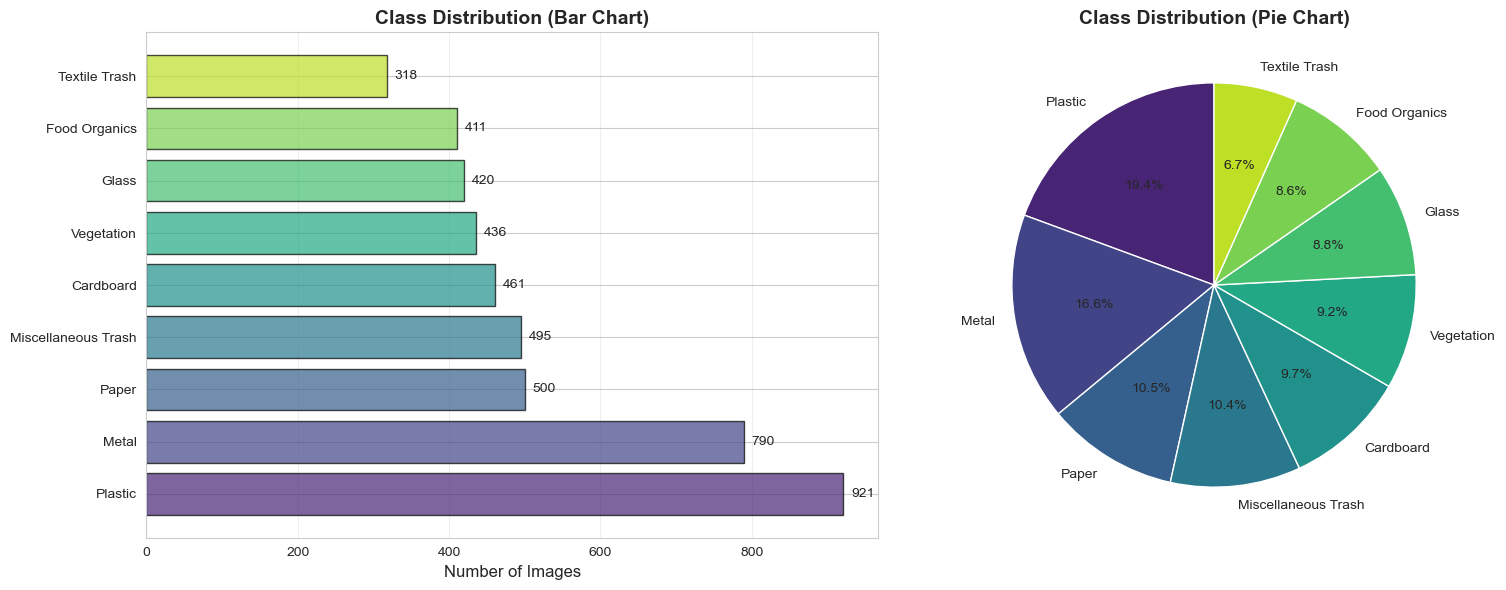

In [6]:
# Plot class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot
categories_sorted = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
cats, counts = zip(*categories_sorted)
colors = sns.color_palette('viridis', len(cats))

ax1.barh(cats, counts, color=colors, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Images', fontsize=12)
ax1.set_title('Class Distribution (Bar Chart)', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, count in enumerate(counts):
    ax1.text(count + 10, i, str(count), va='center', fontsize=10)

# Pie chart
ax2.pie(counts, labels=cats, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Class Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.3 Sample Images from Each Category

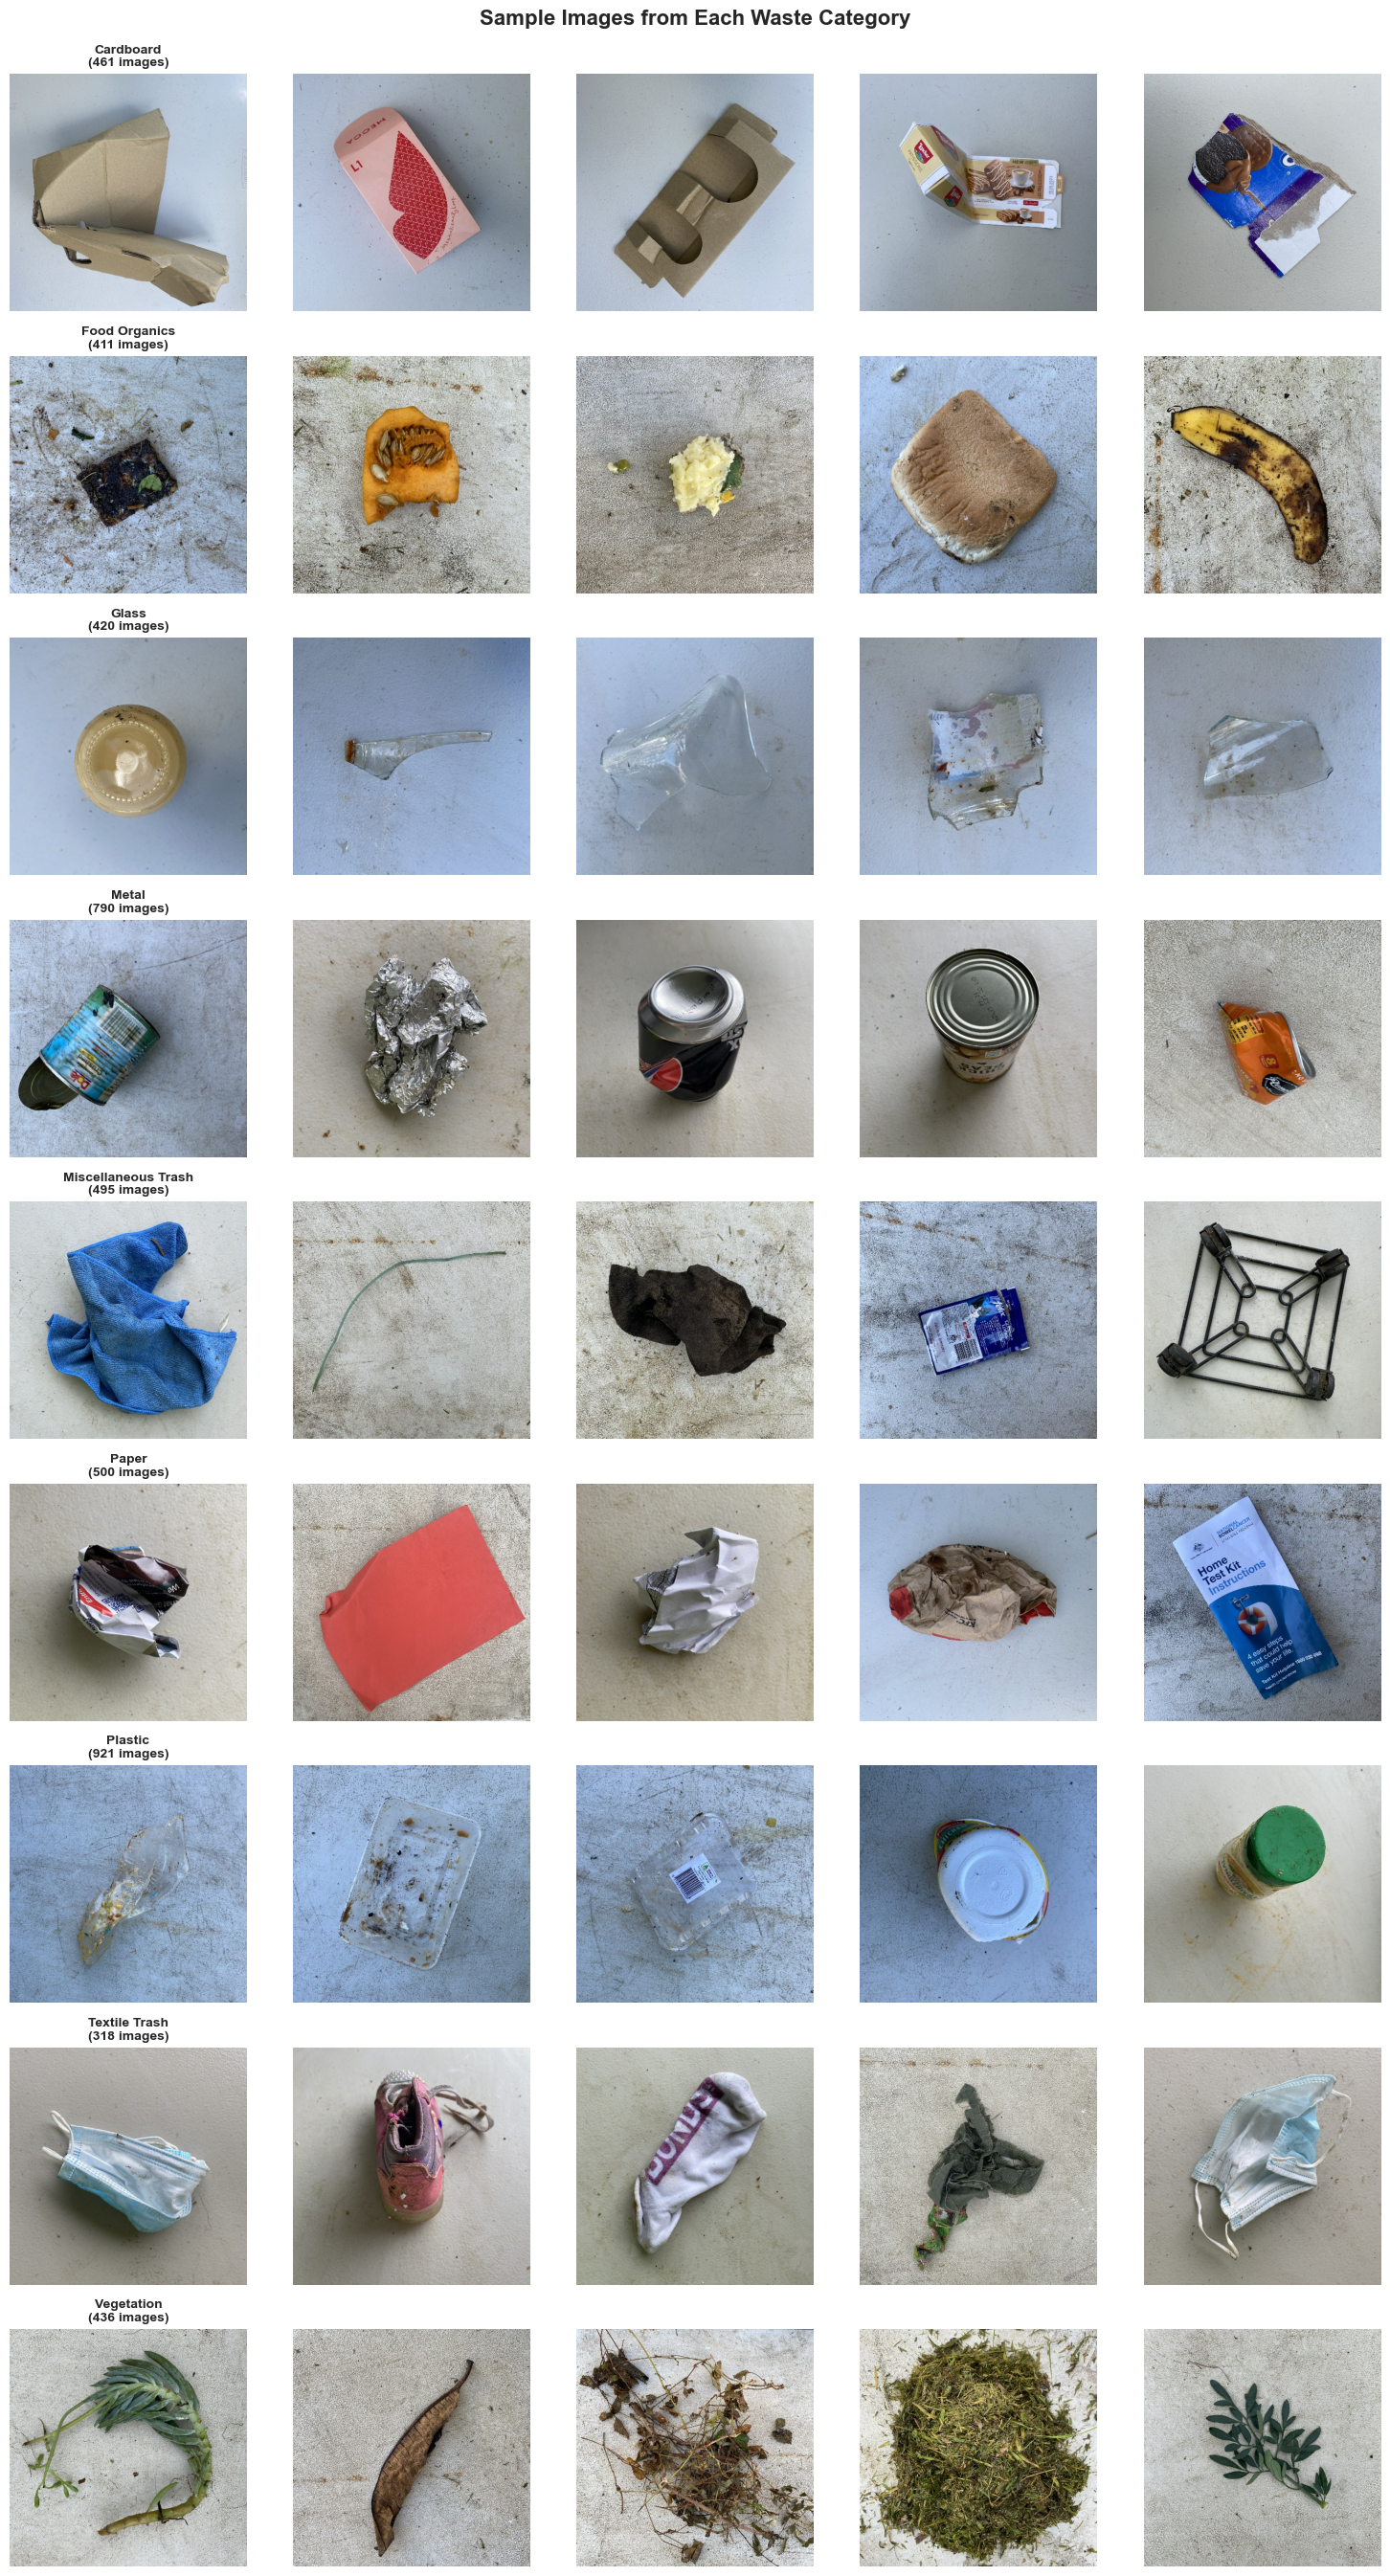

In [7]:
# Display sample images from each category
n_samples = 5
n_categories = len(categories)

fig, axes = plt.subplots(n_categories, n_samples, figsize=(15, 3 * n_categories))
fig.suptitle('Sample Images from Each Waste Category', fontsize=16, fontweight='bold', y=0.995)

for i, cat in enumerate(categories):
    cat_path = os.path.join(dataset_root, cat)
    images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_images = random.sample(images, min(n_samples, len(images)))
    
    for j, img_name in enumerate(sample_images):
        img_path = os.path.join(cat_path, img_name)
        img = Image.open(img_path).convert('RGB')
        
        if n_categories == 1:
            ax = axes[j]
        else:
            ax = axes[i, j]
        
        ax.imshow(img)
        ax.axis('off')
        if j == 0:
            ax.set_title(f"{cat}\n({class_counts[cat]} images)", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Image Properties Analysis

In [ ]:
# Analyze image properties
image_properties = {
    'widths': [],
    'heights': [],
    'aspect_ratios': [],
    'file_sizes_kb': []
}

# Sample a subset of images for efficiency
sample_size = min(500, total_images)
print(f"Analyzing {sample_size} random images...\n")

sampled_images = []
for cat in categories:
    cat_path = os.path.join(dataset_root, cat)
    images = [os.path.join(cat_path, f) for f in os.listdir(cat_path) if f.endswith('.jpg')]
    sampled_images.extend(random.sample(images, min(sample_size // len(categories), len(images))))

for img_path in tqdm(sampled_images, desc="Analyzing images"):
    try:
        img = Image.open(img_path)
        width, height = img.size
        image_properties['widths'].append(width)
        image_properties['heights'].append(height)
        image_properties['aspect_ratios'].append(width / height)
        image_properties['file_sizes_kb'].append(os.path.getsize(img_path) / 1024)
    except Exception as e:
        continue

# Print statistics
print(f"\nImage dimensions:")
print(f"  Width:  min={min(image_properties['widths'])}, max={max(image_properties['widths'])}, "
      f"mean={np.mean(image_properties['widths']):.1f}")
print(f"  Height: min={min(image_properties['heights'])}, max={max(image_properties['heights'])}, "
      f"mean={np.mean(image_properties['heights']):.1f}")
print(f"\nAspect ratio: min={min(image_properties['aspect_ratios']):.2f}, "
      f"max={max(image_properties['aspect_ratios']):.2f}, mean={np.mean(image_properties['aspect_ratios']):.2f}")
print(f"\nFile size (KB): min={min(image_properties['file_sizes_kb']):.1f}, "
      f"max={max(image_properties['file_sizes_kb']):.1f}, mean={np.mean(image_properties['file_sizes_kb']):.1f}")

Analyzing 500 random images...



Analyzing images: 100%|██████████| 495/495 [00:00<00:00, 4335.60it/s]


Image dimensions:
  Width:  min=524, max=524, mean=524.0
  Height: min=524, max=524, mean=524.0

Aspect ratio: min=1.00, max=1.00, mean=1.00

File size (KB): min=47.7, max=242.8, mean=144.4


## 4. Data Preprocessing

### 4.1 Configuration

In [9]:
# Configuration parameters
IMG_SIZE = 128  # Resize all images to 128x128 for consistency
BATCH_SIZE = 32
NUM_WORKERS = 0 if device.type == 'mps' else 4  # MPS doesn't support multiprocessing well
TARGET_DIM = 64  # Target dimensionality for PCA and Autoencoder

print(f"Configuration:")
print(f"  Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Target dimensionality (PCA/AE): {TARGET_DIM}")
print(f"  Device: {device}")
print(f"  Number of classes: {len(categories)}")

Configuration:
  Image size: 128x128
  Batch size: 32
  Target dimensionality (PCA/AE): 64
  Device: mps
  Number of classes: 9


### 4.2 Train/Validation/Test Split

In [ ]:
# Create directories for split datasets
base_dir = './waste_split'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Remove existing split directories if they exist
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Create output directories
for split_dir in [train_dir, val_dir, test_dir]:
    os.makedirs(split_dir, exist_ok=True)

# Split ratios
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

print("Splitting dataset into train/val/test sets...\n")

# Loop through each class folder
split_summary = {}
for class_name in categories:
    class_path = os.path.join(dataset_root, class_name)
    
    # Create class subfolders inside each split
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)
    
    # Get all image files
    images = [f for f in os.listdir(class_path) if f.endswith('.jpg')]
    random.shuffle(images)
    
    total = len(images)
    train_end = floor(total * train_ratio)
    val_end = floor(total * (train_ratio + val_ratio))
    
    # Split lists
    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]
    
    # Copy files to respective folders
    for file_list, dest_dir in [
        (train_files, os.path.join(train_dir, class_name)),
        (val_files, os.path.join(val_dir, class_name)),
        (test_files, os.path.join(test_dir, class_name))
    ]:
        for filename in file_list:
            src = os.path.join(class_path, filename)
            dst = os.path.join(dest_dir, filename)
            shutil.copy2(src, dst)
    
    split_summary[class_name] = {'train': len(train_files), 'val': len(val_files), 'test': len(test_files)}
    print(f"{class_name:20s} - Train: {len(train_files):4d}, Val: {len(val_files):4d}, Test: {len(test_files):4d}")

# Calculate overall statistics
total_train = sum(s['train'] for s in split_summary.values())
total_val = sum(s['val'] for s in split_summary.values())
total_test = sum(s['test'] for s in split_summary.values())
grand_total = total_train + total_val + total_test

print(f"\nTotal - Train: {total_train} ({total_train/grand_total*100:.1f}%), "
      f"Val: {total_val} ({total_val/grand_total*100:.1f}%), "
      f"Test: {total_test} ({total_test/grand_total*100:.1f}%)")
print("Dataset successfully split!")

Splitting dataset into train/val/test sets...

Cardboard            - Train:  322, Val:   69, Test:   70
Food Organics        - Train:  287, Val:   62, Test:   62
Glass                - Train:  294, Val:   63, Test:   63
Metal                - Train:  553, Val:  118, Test:  119
Miscellaneous Trash  - Train:  346, Val:   74, Test:   75
Paper                - Train:  350, Val:   75, Test:   75
Plastic              - Train:  644, Val:  138, Test:  139
Textile Trash        - Train:  222, Val:   48, Test:   48
Vegetation           - Train:  305, Val:   65, Test:   66

Total - Train: 3323 (69.9%), Val: 712 (15.0%), Test: 717 (15.1%)
Dataset successfully split!


### 4.3 Data Augmentation and Transforms

In [11]:
# Data transformations with augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Data transformations without augmentation for validation and test
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Image transformations defined:")
print("\nTraining (with augmentation):")
print("  - Resize, Random horizontal flip, Random rotation (±15°)")
print("  - Color jitter, Random affine, Normalization (ImageNet stats)")
print("\nValidation/Test (no augmentation):")
print("  - Resize, Normalization (ImageNet stats)")

Image transformations defined:

Training (with augmentation):
  - Resize, Random horizontal flip, Random rotation (±15°)
  - Color jitter, Random affine, Normalization (ImageNet stats)

Validation/Test (no augmentation):
  - Resize, Normalization (ImageNet stats)


### 4.4 Visualize Augmentation Effects

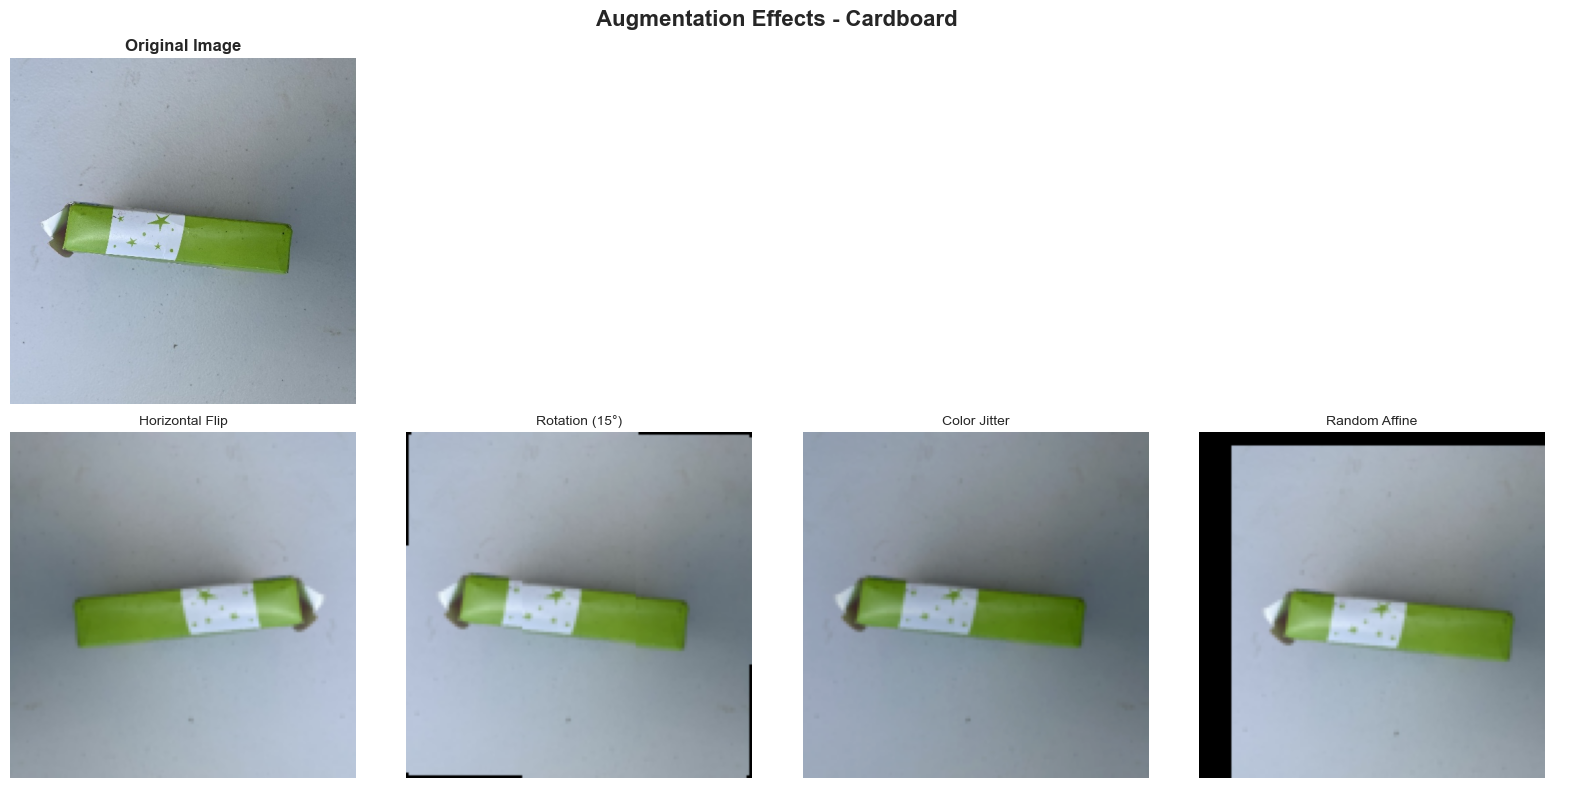

Sample image from: Cardboard
Original size: (524, 524)
After resize: 128x128


In [19]:
# Show original image and augmented versions
sample_class = categories[0]
sample_img_path = os.path.join(dataset_root, sample_class, 
                               os.listdir(os.path.join(dataset_root, sample_class))[0])

# Load original image
original_img = Image.open(sample_img_path)

# Create figure with 2 rows and 4 columns
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Augmentation Effects - {sample_class}', fontsize=16, fontweight='bold')

# Show original image (larger in first row)
axes[0, 0].imshow(original_img)
axes[0, 0].set_title('Original Image', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

# Hide remaining plots in first row
for i in range(1, 4):
    axes[0, i].axis('off')

# Apply individual augmentations for visualization
augmentation_transforms = {
    'Horizontal Flip': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
    ]),
    'Rotation (15°)': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
    ]),
    'Color Jitter': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
    ]),
    'Random Affine': transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.ToTensor(),
    ]),
}

# Apply and display each augmentation
for idx, (aug_name, transform) in enumerate(augmentation_transforms.items()):
    # Set seed for reproducibility of random augmentation
    torch.manual_seed(42 + idx)
    random.seed(42 + idx)
    
    # Apply transformation
    augmented = transform(original_img)
    
    # Convert tensor to numpy for display
    augmented_np = augmented.permute(1, 2, 0).numpy()
    
    axes[1, idx].imshow(augmented_np)
    axes[1, idx].set_title(aug_name, fontsize=10)
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Sample image from: {sample_class}")
print(f"Original size: {original_img.size}")
print(f"After resize: {IMG_SIZE}x{IMG_SIZE}")

### 4.5 Create PyTorch Datasets and DataLoaders

In [12]:
# Create datasets
train_dataset = ImageFolder(train_dir, transform=train_transforms)
val_dataset = ImageFolder(val_dir, transform=val_test_transforms)
test_dataset = ImageFolder(test_dir, transform=val_test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Get class names and create index mapping
class_names = train_dataset.classes
class_to_idx = train_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
num_classes = len(class_names)

print(f"Datasets and DataLoaders created successfully!")
print(f"\nDataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Datasets and DataLoaders created successfully!

Dataset sizes: Train: 3323, Val: 712, Test: 717
Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


## 5. Feature Extraction for Dimensionality Reduction

### 5.1 Extract Flattened Features

In [13]:
def extract_features(dataloader):
    """Extract and flatten features from a dataloader."""
    features_list = []
    labels_list = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            # Flatten images: (batch_size, channels, height, width) -> (batch_size, channels*height*width)
            flattened = images.view(images.size(0), -1)
            features_list.append(flattened.cpu())
            labels_list.append(labels.cpu())
    
    features = torch.cat(features_list, dim=0).numpy()
    labels = torch.cat(labels_list, dim=0).numpy()
    
    return features, labels

print("Extracting features from all datasets...")
print(f"Original feature dimension: {IMG_SIZE * IMG_SIZE * 3}")

# Extract features
X_train_flat, y_train_flat = extract_features(train_loader)
X_val_flat, y_val_flat = extract_features(val_loader)
X_test_flat, y_test_flat = extract_features(test_loader)

print(f"\nExtracted feature shapes:")
print(f"  Train: {X_train_flat.shape}, Labels: {y_train_flat.shape}")
print(f"  Val:   {X_val_flat.shape}, Labels: {y_val_flat.shape}")
print(f"  Test:  {X_test_flat.shape}, Labels: {y_test_flat.shape}")

Extracting features from all datasets...
Original feature dimension: 49152


Extracting features: 100%|██████████| 23/23 [00:02<00:00,  8.54it/s]



Extracted feature shapes:
  Train: (3323, 49152), Labels: (3323,)
  Val:   (712, 49152), Labels: (712,)
  Test:  (717, 49152), Labels: (717,)


### 5.2 Standardize Features

In [14]:
# Standardize features (FIT on train, TRANSFORM on all)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

print("Features standardized successfully!")
print(f"\nTrain set - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"Val set   - Mean: {X_val_scaled.mean():.6f}, Std: {X_val_scaled.std():.6f}")
print(f"Test set  - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

Features standardized successfully!

Train set - Mean: -0.000000, Std: 1.000001
Val set   - Mean: 0.304352, Std: 0.834192
Test set  - Mean: 0.295322, Std: 0.834938


## 6. Dimensionality Reduction

### 6.1 PCA (Principal Component Analysis)

Components for 90% variance: 252
Components for 95% variance: 622
Components for 99% variance: 1831


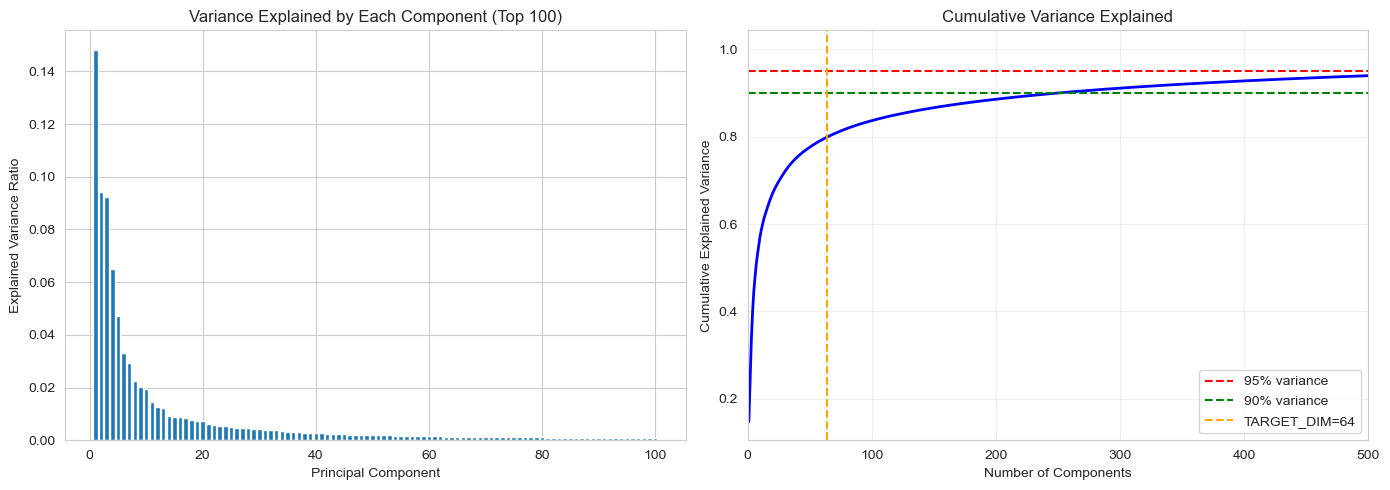


Variance explained with 64 components: 79.87%


In [15]:
# Analyze variance explained by PCA components
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
thresholds = [0.90, 0.95, 0.99]
for thresh in thresholds:
    n_comp = np.argmax(cumulative_variance >= thresh) + 1
    print(f"Components for {thresh*100:.0f}% variance: {n_comp}")

# Plot explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance (first 100 components)
axes[0].bar(range(1, 101), pca_full.explained_variance_ratio_[:100])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Variance Explained by Each Component (Top 100)')

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='g', linestyle='--', label='90% variance')
axes[1].axvline(x=TARGET_DIM, color='orange', linestyle='--', label=f'TARGET_DIM={TARGET_DIM}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].set_xlim([0, 500])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Variance at TARGET_DIM
print(f"\nVariance explained with {TARGET_DIM} components: {cumulative_variance[TARGET_DIM-1]*100:.2f}%")

### 6.2 Apply PCA Transformation

In [16]:
# Apply PCA with TARGET_DIM components
pca = PCA(n_components=TARGET_DIM)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA Transformation Complete:")
print(f"  Original shape: {X_train_scaled.shape}")
print(f"  Reduced shape:  {X_train_pca.shape}")
print(f"  Compression ratio: {X_train_scaled.shape[1] / TARGET_DIM:.1f}x")
print(f"  Variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

PCA Transformation Complete:
  Original shape: (3323, 49152)
  Reduced shape:  (3323, 64)
  Compression ratio: 768.0x
  Variance retained: 79.86%


### 6.3 Autoencoder Architecture

In [17]:
class Autoencoder(nn.Module):
    """Autoencoder for dimensionality reduction."""
    
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder: input_dim -> 512 -> 256 -> 128 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, latent_dim)
        )
        
        # Decoder: latent_dim -> 128 -> 256 -> 512 -> input_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            
            nn.Linear(512, input_dim)
        )
    
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        reconstructed = self.decode(z)
        return reconstructed

# Create autoencoder
input_dim = X_train_scaled.shape[1]
autoencoder = Autoencoder(input_dim, TARGET_DIM).to(device)

# Count parameters
total_params = sum(p.numel() for p in autoencoder.parameters())
trainable_params = sum(p.numel() for p in autoencoder.parameters() if p.requires_grad)
print(f"Autoencoder Architecture:")
print(f"  Input dimension: {input_dim}")
print(f"  Latent dimension: {TARGET_DIM}")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(autoencoder)

Autoencoder Architecture:
  Input dimension: 49152
  Latent dimension: 64
  Total parameters: 50,730,304
  Trainable parameters: 50,730,304
Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=49152, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=128, out_features=64, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

### 6.4 Train Autoencoder

In [18]:
# Create tensor datasets for autoencoder training
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_val_tensor = torch.FloatTensor(X_val_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

ae_train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
ae_val_dataset = TensorDataset(X_val_tensor, X_val_tensor)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
ae_val_loader = DataLoader(ae_val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Training configuration
AE_EPOCHS = 50
ae_optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)
ae_scheduler = optim.lr_scheduler.ReduceLROnPlateau(ae_optimizer, mode='min', factor=0.5, patience=5, verbose=True)
ae_criterion = nn.MSELoss()

# Training loop
ae_train_losses = []
ae_val_losses = []
best_ae_loss = float('inf')

print("Training Autoencoder...")

for epoch in range(AE_EPOCHS):
    # Training
    autoencoder.train()
    train_loss = 0.0
    for data, _ in ae_train_loader:
        data = data.to(device)
        ae_optimizer.zero_grad()
        reconstructed = autoencoder(data)
        loss = ae_criterion(reconstructed, data)
        loss.backward()
        ae_optimizer.step()
        train_loss += loss.item() * data.size(0)
    
    train_loss /= len(ae_train_loader.dataset)
    ae_train_losses.append(train_loss)
    
    # Validation
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for data, _ in ae_val_loader:
            data = data.to(device)
            reconstructed = autoencoder(data)
            loss = ae_criterion(reconstructed, data)
            val_loss += loss.item() * data.size(0)
    
    val_loss /= len(ae_val_loader.dataset)
    ae_val_losses.append(val_loss)
    
    # Scheduler step
    ae_scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_ae_loss:
        best_ae_loss = val_loss
        best_ae_state = autoencoder.state_dict().copy()
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{AE_EPOCHS}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

# Load best model
autoencoder.load_state_dict(best_ae_state)
print("-" * 60)
print(f"Best Validation Loss: {best_ae_loss:.6f}")

Training Autoencoder...


KeyboardInterrupt: 

### 6.5 Autoencoder Training Curves

In [ ]:
# Plot autoencoder training curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, AE_EPOCHS + 1), ae_train_losses, 'b-', label='Train Loss', linewidth=2)
plt.plot(range(1, AE_EPOCHS + 1), ae_val_losses, 'r-', label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Encode Features with Autoencoder

In [ ]:
# Encode features using trained autoencoder
autoencoder.eval()
with torch.no_grad():
    X_train_ae = autoencoder.encode(X_train_tensor.to(device)).cpu().numpy()
    X_val_ae = autoencoder.encode(X_val_tensor.to(device)).cpu().numpy()
    X_test_ae = autoencoder.encode(X_test_tensor.to(device)).cpu().numpy()

print(f"Autoencoder Encoding Complete:")
print(f"  Original shape: {X_train_scaled.shape}")
print(f"  Encoded shape:  {X_train_ae.shape}")
print(f"  Compression ratio: {X_train_scaled.shape[1] / TARGET_DIM:.1f}x")

## 7. CNN Architectures

### 7.1 Original CNN (Full Image Input)

In [ ]:
class WasteCNN(nn.Module):
    """CNN for waste classification using full image input."""
    
    def __init__(self, num_classes):
        super(WasteCNN, self).__init__()
        
        # Convolutional layers
        self.features = nn.Sequential(
            # Block 1: 3 -> 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 128 -> 64
            nn.Dropout2d(0.25),
            
            # Block 2: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 64 -> 32
            nn.Dropout2d(0.25),
            
            # Block 3: 64 -> 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32 -> 16
            nn.Dropout2d(0.25),
            
            # Block 4: 128 -> 256 channels
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16 -> 8
            nn.Dropout2d(0.25),
        )
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

# Create model
num_classes = len(class_names)
cnn_original = WasteCNN(num_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in cnn_original.parameters())
trainable_params = sum(p.numel() for p in cnn_original.parameters() if p.requires_grad)
print(f"WasteCNN (Original Image Input):")
print(f"  Input: {IMG_SIZE}x{IMG_SIZE}x3 images")
print(f"  Output: {num_classes} classes")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

### 7.2 Reduced CNN (For PCA/Autoencoder Features)

In [ ]:
class ReducedCNN(nn.Module):
    """MLP classifier for reduced dimensionality features (PCA/Autoencoder)."""
    
    def __init__(self, input_dim, num_classes):
        super(ReducedCNN, self).__init__()
        
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, num_classes)
        )
    
    def forward(self, x):
        return self.classifier(x)

# Create models for PCA and Autoencoder features
cnn_pca = ReducedCNN(TARGET_DIM, num_classes).to(device)
cnn_ae = ReducedCNN(TARGET_DIM, num_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in cnn_pca.parameters())
print(f"ReducedCNN (For Reduced Features):")
print(f"  Input dimension: {TARGET_DIM}")
print(f"  Output: {num_classes} classes")
print(f"  Total parameters: {total_params:,}")

## 8. Model Training

### 8.1 Training Function

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                num_epochs, model_name, is_image_model=True):
    """
    Train a model with early stopping and learning rate scheduling.
    
    Args:
        model: PyTorch model to train
        train_loader: Training data loader
        val_loader: Validation data loader
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Maximum number of epochs
        model_name: Name for logging
        is_image_model: Whether input is images (True) or features (False)
    
    Returns:
        Dictionary with training history
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    patience = 10
    patience_counter = 0
    
    print(f"Training {model_name}...")
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            if is_image_model:
                inputs = inputs.to(device)
            else:
                inputs = inputs.float().to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        train_loss /= train_total
        train_acc = 100.0 * train_correct / train_total
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                if is_image_model:
                    inputs = inputs.to(device)
                else:
                    inputs = inputs.float().to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        val_loss /= val_total
        val_acc = 100.0 * val_correct / val_total
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # Scheduler step
        scheduler.step(val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    model.load_state_dict(best_model_state)
    print("-" * 60)
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    
    return history

### 8.2 Training Configuration

In [ ]:
# Training hyperparameters
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Loss function
criterion = nn.CrossEntropyLoss()

# Create data loaders for reduced features
y_train_tensor = torch.LongTensor(y_train_flat)
y_val_tensor = torch.LongTensor(y_val_flat)
y_test_tensor = torch.LongTensor(y_test_flat)

# PCA feature loaders
pca_train_dataset = TensorDataset(torch.FloatTensor(X_train_pca), y_train_tensor)
pca_val_dataset = TensorDataset(torch.FloatTensor(X_val_pca), y_val_tensor)
pca_test_dataset = TensorDataset(torch.FloatTensor(X_test_pca), y_test_tensor)

pca_train_loader = DataLoader(pca_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
pca_val_loader = DataLoader(pca_val_dataset, batch_size=BATCH_SIZE, shuffle=False)
pca_test_loader = DataLoader(pca_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Autoencoder feature loaders
ae_train_cls_dataset = TensorDataset(torch.FloatTensor(X_train_ae), y_train_tensor)
ae_val_cls_dataset = TensorDataset(torch.FloatTensor(X_val_ae), y_val_tensor)
ae_test_cls_dataset = TensorDataset(torch.FloatTensor(X_test_ae), y_test_tensor)

ae_train_cls_loader = DataLoader(ae_train_cls_dataset, batch_size=BATCH_SIZE, shuffle=True)
ae_val_cls_loader = DataLoader(ae_val_cls_dataset, batch_size=BATCH_SIZE, shuffle=False)
ae_test_cls_loader = DataLoader(ae_test_cls_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning Rate: {LEARNING_RATE}")
print(f"  Weight Decay: {WEIGHT_DECAY}")
print(f"  Batch Size: {BATCH_SIZE}")

### 8.3 Train Original CNN (Full Images)

In [ ]:
# Train Original CNN
optimizer_orig = optim.Adam(cnn_original.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_orig = optim.lr_scheduler.ReduceLROnPlateau(optimizer_orig, mode='min', factor=0.5, patience=5, verbose=True)

history_original = train_model(
    model=cnn_original,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer_orig,
    scheduler=scheduler_orig,
    num_epochs=NUM_EPOCHS,
    model_name="Original CNN",
    is_image_model=True
)

### 8.4 Train PCA-Reduced CNN

In [ ]:
# Train PCA CNN
optimizer_pca = optim.Adam(cnn_pca.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_pca = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pca, mode='min', factor=0.5, patience=5, verbose=True)

history_pca = train_model(
    model=cnn_pca,
    train_loader=pca_train_loader,
    val_loader=pca_val_loader,
    criterion=criterion,
    optimizer=optimizer_pca,
    scheduler=scheduler_pca,
    num_epochs=NUM_EPOCHS,
    model_name="PCA-Reduced CNN",
    is_image_model=False
)

### 8.5 Train Autoencoder-Reduced CNN

In [ ]:
# Train Autoencoder CNN
optimizer_ae = optim.Adam(cnn_ae.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ae, mode='min', factor=0.5, patience=5, verbose=True)

history_ae = train_model(
    model=cnn_ae,
    train_loader=ae_train_cls_loader,
    val_loader=ae_val_cls_loader,
    criterion=criterion,
    optimizer=optimizer_ae,
    scheduler=scheduler_ae,
    num_epochs=NUM_EPOCHS,
    model_name="Autoencoder-Reduced CNN",
    is_image_model=False
)

### 8.6 Training Curves Comparison

In [ ]:
# Plot training curves for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

histories = [
    (history_original, 'Original CNN'),
    (history_pca, 'PCA-Reduced CNN'),
    (history_ae, 'Autoencoder-Reduced CNN')
]

colors = ['blue', 'green', 'orange']

for idx, (history, name) in enumerate(histories):
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, idx].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, idx].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].set_title(f'{name} - Loss')
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, idx].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
    axes[1, idx].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[1, idx].set_xlabel('Epoch')
    axes[1, idx].set_ylabel('Accuracy (%)')
    axes[1, idx].set_title(f'{name} - Accuracy')
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Model Evaluation

### 9.1 Evaluation Function

In [ ]:
def evaluate_model(model, test_loader, class_names, model_name, is_image_model=True):
    """
    Evaluate a model on test data and generate classification report.
    
    Args:
        model: Trained PyTorch model
        test_loader: Test data loader
        class_names: List of class names
        model_name: Name for display
        is_image_model: Whether input is images (True) or features (False)
    
    Returns:
        Dictionary with predictions, labels, and metrics
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            if is_image_model:
                inputs = inputs.to(device)
            else:
                inputs = inputs.float().to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    print(f"\n{model_name} - Test Results")
    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")
    
    print(f"\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    return {
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

### 9.2 Evaluate All Models

In [ ]:
# Evaluate all models on test set
results_original = evaluate_model(cnn_original, test_loader, class_names, "Original CNN", is_image_model=True)
results_pca = evaluate_model(cnn_pca, pca_test_loader, class_names, "PCA-Reduced CNN", is_image_model=False)
results_ae = evaluate_model(cnn_ae, ae_test_cls_loader, class_names, "Autoencoder-Reduced CNN", is_image_model=False)

### 9.3 Confusion Matrices

In [ ]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

results_list = [
    (results_original, 'Original CNN'),
    (results_pca, 'PCA-Reduced CNN'),
    (results_ae, 'Autoencoder-Reduced CNN')
]

for idx, (results, name) in enumerate(results_list):
    cm = confusion_matrix(results['labels'], results['predictions'])
    
    # Normalize confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[idx])
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    axes[idx].set_title(f'{name}\nAccuracy: {results["accuracy"]*100:.2f}%')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 10. Results Comparison

### 10.1 Performance Summary

In [ ]:
# Create comparison DataFrame
comparison_data = {
    'Model': ['Original CNN', 'PCA-Reduced CNN', 'Autoencoder-Reduced CNN'],
    'Input Dimension': [f'{IMG_SIZE}x{IMG_SIZE}x3', f'{TARGET_DIM}', f'{TARGET_DIM}'],
    'Accuracy (%)': [
        results_original['accuracy'] * 100,
        results_pca['accuracy'] * 100,
        results_ae['accuracy'] * 100
    ],
    'Precision (%)': [
        results_original['precision'] * 100,
        results_pca['precision'] * 100,
        results_ae['precision'] * 100
    ],
    'Recall (%)': [
        results_original['recall'] * 100,
        results_pca['recall'] * 100,
        results_ae['recall'] * 100
    ],
    'F1-Score (%)': [
        results_original['f1'] * 100,
        results_pca['f1'] * 100,
        results_ae['f1'] * 100
    ],
    'Parameters': [
        sum(p.numel() for p in cnn_original.parameters()),
        sum(p.numel() for p in cnn_pca.parameters()),
        sum(p.numel() for p in cnn_ae.parameters())
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(2)
print("Model Comparison Summary:")
print("=" * 100)
display(comparison_df)

### 10.2 Metrics Visualization

In [ ]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics comparison bar plot
metrics = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x = np.arange(len(metrics))
width = 0.25

for idx, model in enumerate(comparison_df['Model']):
    values = [comparison_df.loc[idx, m] for m in metrics]
    axes[0].bar(x + idx*width, values, width, label=model)

axes[0].set_ylabel('Score (%)')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'])
axes[0].legend()
axes[0].set_ylim([0, 100])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for idx, model in enumerate(comparison_df['Model']):
    values = [comparison_df.loc[idx, m] for m in metrics]
    for i, v in enumerate(values):
        axes[0].text(x[i] + idx*width, v + 1, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

# Parameters comparison
models = comparison_df['Model']
params = comparison_df['Parameters']
colors = ['steelblue', 'seagreen', 'coral']

bars = axes[1].bar(models, params, color=colors)
axes[1].set_ylabel('Number of Parameters')
axes[1].set_title('Model Complexity Comparison')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, param in zip(bars, params):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                 f'{param:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 10.3 Per-Class Performance

In [ ]:
# Per-class F1 scores comparison
from sklearn.metrics import f1_score as f1_per_class

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(class_names))
width = 0.25

# Calculate per-class F1 scores
f1_original = f1_per_class(results_original['labels'], results_original['predictions'], average=None)
f1_pca = f1_per_class(results_pca['labels'], results_pca['predictions'], average=None)
f1_ae = f1_per_class(results_ae['labels'], results_ae['predictions'], average=None)

ax.bar(x - width, f1_original * 100, width, label='Original CNN', color='steelblue')
ax.bar(x, f1_pca * 100, width, label='PCA-Reduced CNN', color='seagreen')
ax.bar(x + width, f1_ae * 100, width, label='Autoencoder-Reduced CNN', color='coral')

ax.set_xlabel('Class')
ax.set_ylabel('F1-Score (%)')
ax.set_title('Per-Class F1-Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 100])

plt.tight_layout()
plt.show()

## 11. Conclusions

In [ ]:
# Final Summary
print("WASTE CLASSIFICATION - FINAL SUMMARY")
print()

# Best model
best_idx = comparison_df['Accuracy (%)'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']
best_acc = comparison_df.loc[best_idx, 'Accuracy (%)']

print(f"Dataset: RealWaste ({len(class_names)} classes)")
print(f"   Total samples: {len(X_train_flat) + len(X_val_flat) + len(X_test_flat)}")
print(f"   Train/Val/Test split: 70%/15%/15%")

print(f"\nBest Performing Model: {best_model}")
print(f"   Test Accuracy: {best_acc:.2f}%")

print(f"\nModel Performance Summary:")
for idx, row in comparison_df.iterrows():
    print(f"   - {row['Model']}: {row['Accuracy (%)']:.2f}% accuracy, {row['Parameters']:,} parameters")

print(f"\nKey Findings:")
print(f"   - Dimensionality reduction from {IMG_SIZE*IMG_SIZE*3} to {TARGET_DIM} features")
print(f"   - PCA variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Accuracy comparison
orig_acc = comparison_df.loc[0, 'Accuracy (%)']
pca_acc = comparison_df.loc[1, 'Accuracy (%)']
ae_acc = comparison_df.loc[2, 'Accuracy (%)']

if orig_acc > pca_acc and orig_acc > ae_acc:
    print(f"   - Original CNN with full images achieved the best accuracy")
    print(f"   - Dimensionality reduction resulted in some information loss")
elif pca_acc > ae_acc:
    print(f"   - PCA-reduced features performed competitively with much fewer parameters")
else:
    print(f"   - Autoencoder-reduced features learned useful representations")

print(f"\nObservations:")
print(f"   - The Original CNN has more parameters but can learn spatial features")
print(f"   - Reduced models are faster to train and require less memory")
print(f"   - Choice of model depends on accuracy vs. efficiency trade-off")